Запуск SAM3 через ultralytics

In [14]:
from ultralytics.models.sam import SAM3SemanticPredictor
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Сегментация контактных площадок

In [15]:
def save_segmentation_results(results, output_prefix='output'):
    """
    Универсальная функция сохранения результатов сегментации.
    
    Сохраняет:
    1. Оригинальное изображение с прозрачными областями вместо сегментированных объектов
    2. Только сегментированные объекты на прозрачном фоне
    3. Бинарную маску сегментированных областей
    
    Args:
        results: результат model.predict() от Ultralytics (объект Results)
        output_prefix: префикс для имён выходных файлов
    """
    masks_tensor = results[0].masks.data
    orig_img = results[0].orig_img
    height, width = orig_img.shape[:2]
    
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    for mask_tensor in masks_tensor:
        mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
        combined_mask = cv2.bitwise_or(combined_mask, mask_np)
    
    orig_with_alpha = cv2.cvtColor(orig_img, cv2.COLOR_BGR2BGRA)
    alpha_channel = np.where(combined_mask > 0, 0, 255).astype(np.uint8)
    orig_with_alpha[:, :, 3] = alpha_channel
    
    objects_only_layer = np.zeros((height, width, 4), dtype=np.uint8)
    object_color = [255, 255, 255, 255]
    
    for c in range(3):
        objects_only_layer[:, :, c] = np.where(combined_mask > 0, object_color[c], 0)
    objects_only_layer[:, :, 3] = combined_mask
    
    binary_mask = combined_mask.copy()
    
    cv2.imwrite(f'{output_prefix}_without_objects.png', orig_with_alpha, 
                [cv2.IMWRITE_PNG_COMPRESSION, 3])
    cv2.imwrite(f'{output_prefix}_objects_only.png', objects_only_layer,
                [cv2.IMWRITE_PNG_COMPRESSION, 3])
    cv2.imwrite(f'{output_prefix}_binary_mask.png', binary_mask)
    
    white_bg = np.ones_like(orig_img) * 255
    alpha_normalized = alpha_channel[:, :, np.newaxis] / 255.0
    orig_with_white_bg = (orig_img * alpha_normalized + 
                         white_bg * (1 - alpha_normalized)).astype(np.uint8)
    cv2.imwrite(f'{output_prefix}_white_bg.jpg', orig_with_white_bg)
    
    print(f"Сохранено:")
    print(f"1. {output_prefix}_without_objects.png - изображение без сегментированных объектов")
    print(f"2. {output_prefix}_objects_only.png - только сегментированные объекты")
    print(f"3. {output_prefix}_binary_mask.png - бинарная маска")
    print(f"4. {output_prefix}_white_bg.jpg - версия с белым фоном")
    
    return {
        'without_objects': orig_with_alpha,
        'objects_only': objects_only_layer,
        'binary_mask': binary_mask,
        'original_img': orig_img,
        'alpha_channel': alpha_channel
    }

In [16]:
# Initialize predictor with configuration
overrides = dict(
    conf=0.25,
    task="segment",
    mode="predict",
    model="models/sam3.pt",
    half=True,  # Use FP16 for faster inference
    save=True,
)
predictor = SAM3SemanticPredictor(overrides=overrides)

# Set image once for multiple queries
predictor.set_image("example.jpg")

# Query with a single concept
sam_results_pads = predictor(text=["small silver element"])

Ultralytics 8.4.8 🚀 Python-3.11.9 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /home/alex/study/pcb-generation/example.jpg: 644x644 58 small silver elements, 61.7ms
Speed: 1.5ms preprocess, 61.7ms inference, 2.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to /home/alex/study/pcb-generation/runs/segment/predict5


In [17]:
save_segmentation_results(sam_results_pads, 'sam_pads')

Сохранено:
1. sam_pads_without_objects.png - изображение без сегментированных объектов
2. sam_pads_objects_only.png - только сегментированные объекты
3. sam_pads_binary_mask.png - бинарная маска
4. sam_pads_white_bg.jpg - версия с белым фоном


{'without_objects': array([[[ 55, 149,  30, 255],
         [ 50, 144,  25, 255],
         [ 43, 138,  17, 255],
         ...,
         [ 35, 133,   3, 255],
         [ 38, 134,   4, 255],
         [ 39, 135,   5, 255]],
 
        [[ 54, 148,  29, 255],
         [ 49, 144,  23, 255],
         [ 45, 140,  19, 255],
         ...,
         [ 36, 134,   4, 255],
         [ 41, 137,   6, 255],
         [ 44, 140,   9, 255]],
 
        [[ 64, 157,  36, 255],
         [ 54, 147,  26, 255],
         [ 40, 135,  14, 255],
         ...,
         [ 34, 130,   0, 255],
         [ 40, 135,   1, 255],
         [ 44, 139,   5, 255]],
 
        ...,
 
        [[  9,  93,   5, 255],
         [ 14,  98,  10, 255],
         [ 19, 103,  15, 255],
         ...,
         [  8, 107,   3, 255],
         [  6, 105,   3, 255],
         [  7, 106,   4, 255]],
 
        [[ 10,  94,   6, 255],
         [  8,  92,   4, 255],
         [  4,  88,   0, 255],
         ...,
         [  8, 109,   4, 255],
         [  7, 1

In [18]:

# def extract_and_save_masks(results, output_prefix='output'):
#     """
#     Извлекает маски из результатов Ultralytics SAM 3 и сохраняет два изображения:
#     1. Слой только с сегментированными объектами (на прозрачном фоне)
#     2. Оригинальное изображение без этих объектов (с прозрачными дырками)
    
#     Args:
#         results: результат model.predict() от Ultralytics
#         output_prefix: префикс для имён выходных файлов
#     """
#     # Получаем данные из results
#     masks_tensor = results[0].masks.data
#     orig_img = results[0].orig_img  # BGR формат
#     height, width = orig_img.shape[:2]
    
#     # 1. Создаём объединённую маску всех объектов
#     combined_mask = np.zeros((height, width), dtype=np.uint8)
#     for mask_tensor in masks_tensor:
#         mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
#         combined_mask = cv2.bitwise_or(combined_mask, mask_np)
    
#     # 2. Слой ТОЛЬКО с объектами (серебристый цвет)
#     layer_objects = np.zeros((height, width, 4), dtype=np.uint8)
#     object_color = [192, 192, 192, 255]  # Серебристый, непрозрачный
    
#     for c in range(3):
#         layer_objects[:, :, c] = np.where(combined_mask > 0, object_color[c], 0)
#     layer_objects[:, :, 3] = combined_mask
    
#     # 3. Оригинал БЕЗ объектов (с прозрачностью вместо них)
#     orig_with_alpha = cv2.cvtColor(orig_img, cv2.COLOR_BGR2BGRA)
#     inverted_mask = cv2.bitwise_not(combined_mask)
#     orig_with_alpha[:, :, 3] = cv2.bitwise_and(
#         orig_with_alpha[:, :, 3], 
#         inverted_mask
#     )
    
#     # 4. Сохранение
#     cv2.imwrite(f'{output_prefix}_objects_layer.png', layer_objects)
#     cv2.imwrite(f'{output_prefix}_without_objects.png', orig_with_alpha)
    
#     print(f"Сохранено:")
#     print(f"1. {output_prefix}_objects_layer.png - слой с объектами")
#     print(f"2. {output_prefix}_without_objects.png - оригинал без объектов")
    
#     return layer_objects, orig_with_alpha, combined_mask

# # Использование:
# extract_and_save_masks(results, 'contact_pads')

In [19]:
def extract_and_save_masks_fixed(results, output_prefix='output'):
    """
    Извлекает маски и сохраняет с ПРАВИЛЬНОЙ прозрачностью.
    """
    masks_tensor = results[0].masks.data
    orig_img = results[0].orig_img
    height, width = orig_img.shape[:2]
    
    # 1. Объединённая маска
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    for mask_tensor in masks_tensor:
        mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
        combined_mask = cv2.bitwise_or(combined_mask, mask_np)
    
    # 2. Оригинал БЕЗ объектов (КЛЮЧЕВОЕ ИЗМЕНЕНИЕ)
    # Создаём изображение с альфа-каналом
    orig_with_alpha = cv2.cvtColor(orig_img, cv2.COLOR_BGR2BGRA)
    
    # Где есть маска (площадки) - делаем пиксели полностью прозрачными (alpha=0)
    # Где нет маски - оставляем непрозрачными (alpha=255)
    alpha_channel = np.where(combined_mask > 0, 0, 255).astype(np.uint8)
    orig_with_alpha[:, :, 3] = alpha_channel
    
    # 3. Сохраняем С ОБЯЗАТЕЛЬНЫМ параметром для прозрачности
    cv2.imwrite(f'{output_prefix}_without_objects.png', orig_with_alpha, 
                [cv2.IMWRITE_PNG_COMPRESSION, 0])  # Без сжатия для надёжности
    
    print(f"Сохранено: {output_prefix}_without_objects.png")
    print(f"Размер альфа-канала: {np.sum(alpha_channel == 0)} прозрачных пикселей")
    
    return orig_with_alpha, combined_mask

extract_and_save_masks_fixed(sam_results_pads, 'contact_pads')

Сохранено: contact_pads_without_objects.png
Размер альфа-канала: 47474 прозрачных пикселей


(array([[[ 55, 149,  30, 255],
         [ 50, 144,  25, 255],
         [ 43, 138,  17, 255],
         ...,
         [ 35, 133,   3, 255],
         [ 38, 134,   4, 255],
         [ 39, 135,   5, 255]],
 
        [[ 54, 148,  29, 255],
         [ 49, 144,  23, 255],
         [ 45, 140,  19, 255],
         ...,
         [ 36, 134,   4, 255],
         [ 41, 137,   6, 255],
         [ 44, 140,   9, 255]],
 
        [[ 64, 157,  36, 255],
         [ 54, 147,  26, 255],
         [ 40, 135,  14, 255],
         ...,
         [ 34, 130,   0, 255],
         [ 40, 135,   1, 255],
         [ 44, 139,   5, 255]],
 
        ...,
 
        [[  9,  93,   5, 255],
         [ 14,  98,  10, 255],
         [ 19, 103,  15, 255],
         ...,
         [  8, 107,   3, 255],
         [  6, 105,   3, 255],
         [  7, 106,   4, 255]],
 
        [[ 10,  94,   6, 255],
         [  8,  92,   4, 255],
         [  4,  88,   0, 255],
         ...,
         [  8, 109,   4, 255],
         [  7, 108,   3, 255],
    

# Сегментация медных дорожек

In [20]:
predictor.set_image("example.jpg")

# Query with a single concept
sam_results_copper_traces = predictor(text=["light green thick line"])

extract_and_save_masks_fixed(sam_results_copper_traces, 'copper_traces')

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /home/alex/study/pcb-generation/example.jpg: 644x644 13 light green thick lines, 63.8ms
Speed: 1.5ms preprocess, 63.8ms inference, 1.5ms postprocess per image at shape (1, 3, 644, 644)
Results saved to /home/alex/study/pcb-generation/runs/segment/predict5
Сохранено: copper_traces_without_objects.png
Размер альфа-канала: 22011 прозрачных пикселей


(array([[[ 55, 149,  30, 255],
         [ 50, 144,  25, 255],
         [ 43, 138,  17, 255],
         ...,
         [ 35, 133,   3, 255],
         [ 38, 134,   4, 255],
         [ 39, 135,   5, 255]],
 
        [[ 54, 148,  29, 255],
         [ 49, 144,  23, 255],
         [ 45, 140,  19, 255],
         ...,
         [ 36, 134,   4, 255],
         [ 41, 137,   6, 255],
         [ 44, 140,   9, 255]],
 
        [[ 64, 157,  36, 255],
         [ 54, 147,  26, 255],
         [ 40, 135,  14, 255],
         ...,
         [ 34, 130,   0, 255],
         [ 40, 135,   1, 255],
         [ 44, 139,   5, 255]],
 
        ...,
 
        [[  9,  93,   5, 255],
         [ 14,  98,  10, 255],
         [ 19, 103,  15, 255],
         ...,
         [  8, 107,   3, 255],
         [  6, 105,   3, 255],
         [  7, 106,   4, 255]],
 
        [[ 10,  94,   6, 255],
         [  8,  92,   4, 255],
         [  4,  88,   0, 255],
         ...,
         [  8, 109,   4, 255],
         [  7, 108,   3, 255],
    

In [21]:
def auto_binarize_two_colors(image_path, output_prefix='binary_result'):
    """
    Автоматически бинаризует изображение на два доминирующих цвета.
    Игнорирует прозрачные области (альфа=0).
    
    Возвращает:
    - mask_dark: маска тёмных областей (медные полигоны)
    - mask_light: маска светлых областей (паяльная маска + дорожки)
    - optimal_threshold: найденный оптимальный порог
    """
    # 1. Загрузка с прозрачностью
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    
    if img is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")
    
    print(f"Загружено: {img.shape}")
    
    # 2. Обработка прозрачности
    if img.shape[2] == 4:
        bgr = img[:, :, :3]
        alpha = img[:, :, 3]
        
        # Маска непрозрачных областей
        opaque_mask = (alpha > 0).astype(np.uint8) * 255
        
        # Белый фон для непрозрачных алгоритмов
        white_bg = np.ones_like(bgr) * 255
        alpha_norm = alpha[:, :, np.newaxis] / 255.0
        img_processed = (bgr * alpha_norm + white_bg * (1 - alpha_norm)).astype(np.uint8)
    else:
        bgr = img
        opaque_mask = np.ones(img.shape[:2], dtype=np.uint8) * 255
        img_processed = bgr
    
    # 3. Конвертация в grayscale (только для непрозрачных областей)
    gray = cv2.cvtColor(img_processed, cv2.COLOR_BGR2GRAY)
    gray_masked = cv2.bitwise_and(gray, gray, mask=opaque_mask)
    
    # 4. Автоматический подбор порога методом Оцу (на маскированных данных)
    # Собираем все непрозрачные пиксели в одномерный массив
    opaque_pixels = gray_masked[opaque_mask > 0]
    
    if len(opaque_pixels) == 0:
        raise ValueError("Нет непрозрачных пикселей для анализа")
    
    # Метод Оцу на непрозрачных пикселях
    optimal_threshold, _ = cv2.threshold(
        opaque_pixels.reshape(-1, 1), 
        0, 255, 
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    print(f"Порог Оцу: {optimal_threshold:.1f}")
    
    # 5. Альтернативный метод: K-means на 2 кластера (более устойчив для двух цветов)
    # Преобразуем пиксели в float
    pixels_float = opaque_pixels.astype(np.float32).reshape(-1, 1)
    
    # K-means с 2 кластерами
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels_float, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Определяем, какой кластер светлее
    centers_sorted = np.sort(centers.flatten())
    kmeans_threshold = np.mean(centers_sorted)
    
    print(f"K-means центры: {centers.flatten()}")
    print(f"Порог K-means: {kmeans_threshold:.1f}")
    
    # 6. Выбираем лучший порог (среднее между методами)
    final_threshold = int((optimal_threshold + kmeans_threshold) / 2)
    print(f"Финальный порог: {final_threshold}")
    
    # 7. Применяем пороговую обработку
    _, binary = cv2.threshold(gray_masked, final_threshold, 255, cv2.THRESH_BINARY)
    
    # 8. Создаём маски (только для непрозрачных областей)
    # mask_light: светлые области (значение 1 в бинарной маске)
    mask_light = cv2.bitwise_and(binary, binary, mask=opaque_mask)
    
    # mask_dark: тёмные области (инверсия, но только в непрозрачных областях)
    mask_dark = cv2.bitwise_not(binary)
    mask_dark = cv2.bitwise_and(mask_dark, mask_dark, mask=opaque_mask)
    
    # 9. Визуализация
    visualization = img_processed.copy()
    visualization[mask_dark > 0] = [255, 0, 0]    # Синий для тёмного
    visualization[mask_light > 0] = [0, 255, 255] # Жёлтый для светлого
    
    # 10. Анализ и статистика
    analyze_results(gray_masked, opaque_pixels, final_threshold, mask_dark, mask_light)
    
    # 11. Сохранение результатов
    save_results(output_prefix, img_processed, mask_dark, mask_light, visualization)
    
    return {
        'img_processed': img_processed,
        'mask_dark': mask_dark,
        'mask_light': mask_light,
        'threshold': final_threshold,
        'visualization': visualization,
        'gray_masked': gray_masked
    }

def analyze_results(gray_masked, opaque_pixels, threshold, mask_dark, mask_light):
    """Анализ и статистика результатов."""
    # Гистограмма непрозрачных пикселей
    hist = cv2.calcHist([gray_masked], [0], None, [256], [0, 256])
    
    # Статистика
    dark_pixels = np.sum(mask_dark > 0)
    light_pixels = np.sum(mask_light > 0)
    total_opaque = len(opaque_pixels)
    
    print(f"\n=== СТАТИСТИКА ===")
    print(f"Всего непрозрачных пикселей: {total_opaque}")
    print(f"Тёмных пикселей: {dark_pixels} ({dark_pixels/total_opaque*100:.1f}%)")
    print(f"Светлых пикселей: {light_pixels} ({light_pixels/total_opaque*100:.1f}%)")
    print(f"Средняя яркость тёмных: {np.mean(opaque_pixels[opaque_pixels < threshold]):.1f}")
    print(f"Средняя яркость светлых: {np.mean(opaque_pixels[opaque_pixels >= threshold]):.1f}")
    
    # Построение гистограммы
    plt.figure(figsize=(10, 6))
    plt.plot(hist, color='black', linewidth=2, label='Гистограмма')
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Порог ({threshold})')
    
    # Зоны для наглядности
    plt.axvspan(0, threshold, alpha=0.2, color='blue', label='Тёмная зона')
    plt.axvspan(threshold, 255, alpha=0.2, color='yellow', label='Светлая зона')
    
    plt.xlabel('Яркость (0-255)')
    plt.ylabel('Количество пикселей')
    plt.title('Гистограмма яркости с автоматическим порогом')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('histogram_analysis.png', dpi=150)
    plt.show()

def save_results(prefix, img, mask_dark, mask_light, visualization):
    """Сохранение всех результатов."""
    # Основные маски
    cv2.imwrite(f'{prefix}_dark_mask.png', mask_dark)
    cv2.imwrite(f'{prefix}_light_mask.png', mask_light)
    cv2.imwrite(f'{prefix}_visualization.jpg', visualization)
    
    # Слои с цветами
    # Тёмный слой (синий)
    dark_layer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.uint8)
    dark_layer[:, :, 0] = 255  # Синий в BGR
    dark_layer[:, :, 3] = mask_dark
    cv2.imwrite(f'{prefix}_dark_layer.png', dark_layer)
    
    # Светлый слой (жёлтый)
    light_layer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.uint8)
    light_layer[:, :, 1] = 255  # Зелёный
    light_layer[:, :, 2] = 255  # Красный (жёлтый = 0,255,255 в BGR)
    light_layer[:, :, 3] = mask_light
    cv2.imwrite(f'{prefix}_light_layer.png', light_layer)
    
    print(f"\n=== СОХРАНЕНО ===")
    print(f"{prefix}_dark_mask.png - бинарная маска тёмных областей")
    print(f"{prefix}_light_mask.png - бинарная маска светлых областей")
    print(f"{prefix}_dark_layer.png - слой тёмных областей (синий)")
    print(f"{prefix}_light_layer.png - слой светлых областей (жёлтый)")
    print(f"{prefix}_visualization.jpg - визуализация разделения")

### Построение бинарной маски на изображении  с прозрачными пэдами

Загружено: (600, 600, 4)
Порог Оцу: 75.0
K-means центры: [     88.417      63.762]
Порог K-means: 76.1
Финальный порог: 75

=== СТАТИСТИКА ===
Всего непрозрачных пикселей: 312526
Тёмных пикселей: 134883 (43.2%)
Светлых пикселей: 177643 (56.8%)
Средняя яркость тёмных: 62.9
Средняя яркость светлых: 87.7


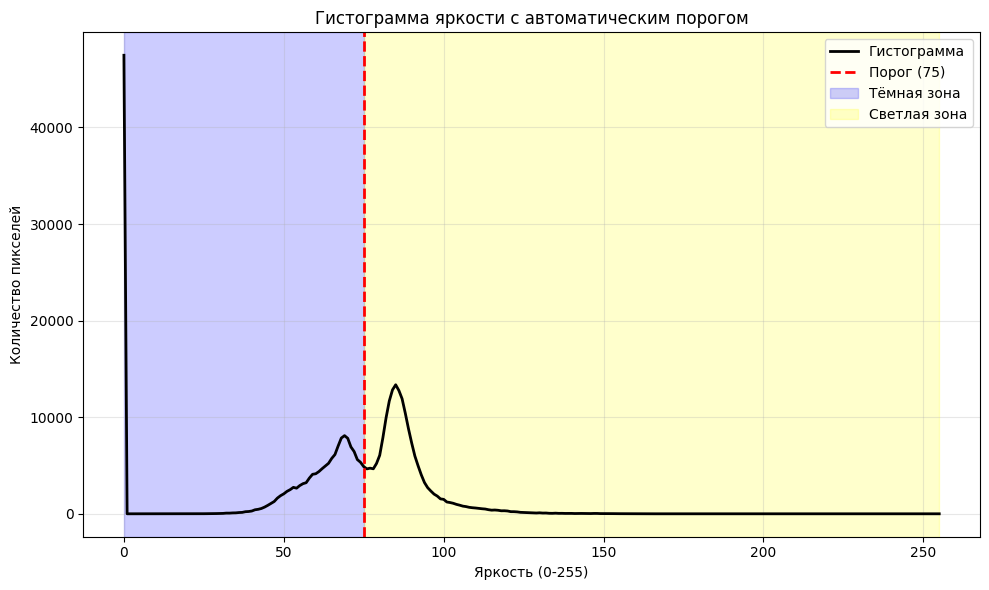


=== СОХРАНЕНО ===
pcb_auto_binary_dark_mask.png - бинарная маска тёмных областей
pcb_auto_binary_light_mask.png - бинарная маска светлых областей
pcb_auto_binary_dark_layer.png - слой тёмных областей (синий)
pcb_auto_binary_light_layer.png - слой светлых областей (жёлтый)
pcb_auto_binary_visualization.jpg - визуализация разделения


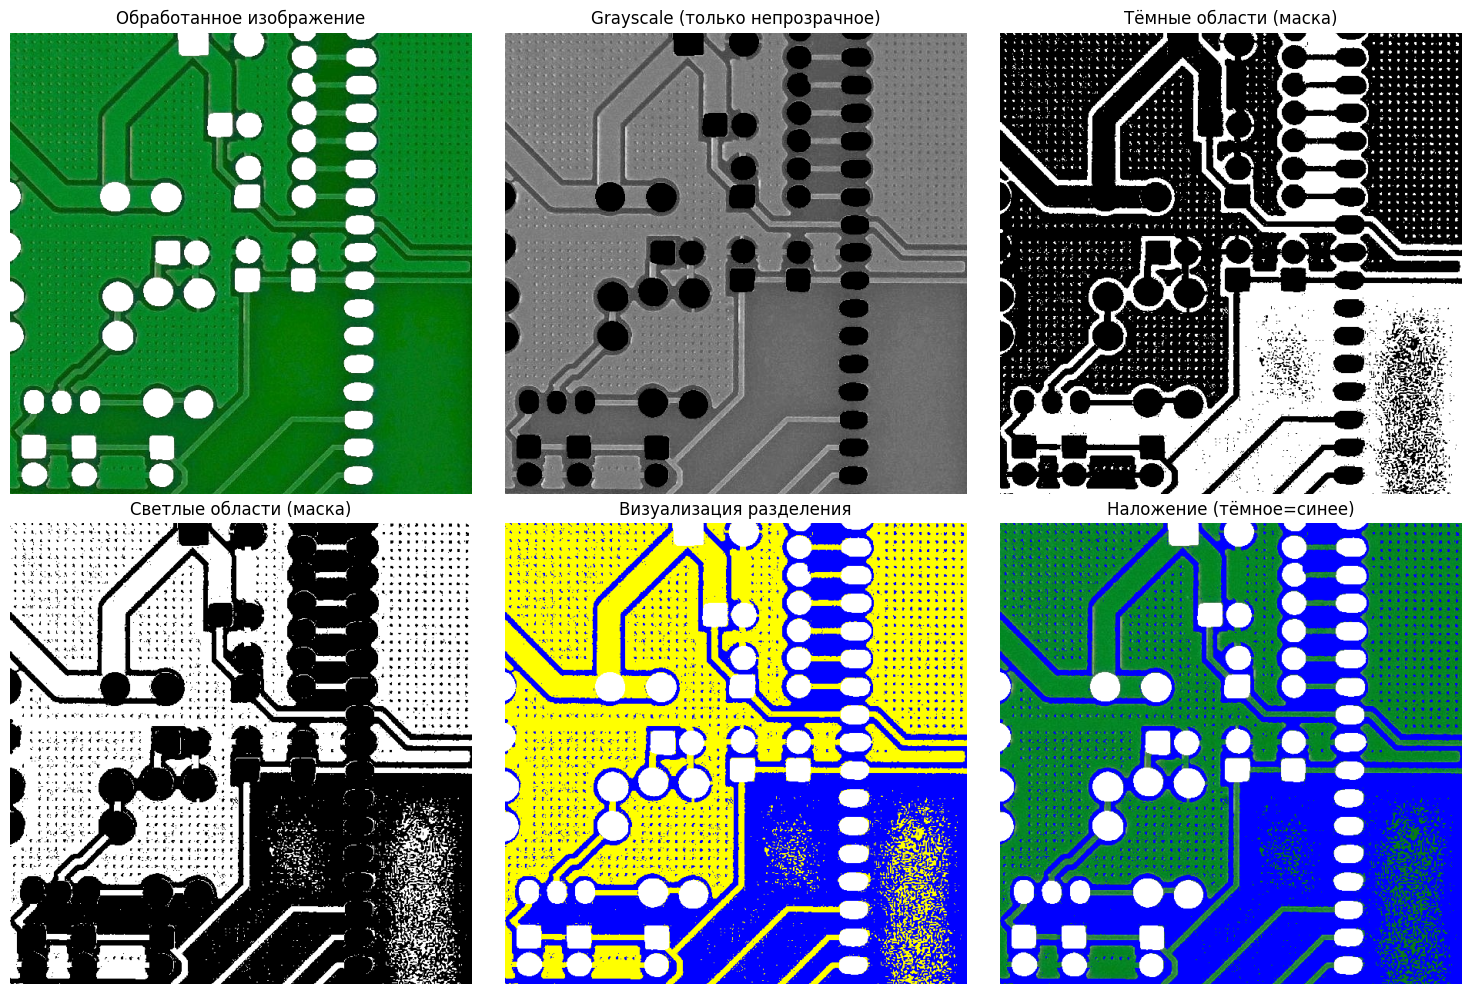

In [22]:
image_path = "contact_pads_without_objects.png"

try:
    results = auto_binarize_two_colors(image_path, 'pcb_auto_binary')
    
    # Дополнительная визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0,0].imshow(cv2.cvtColor(results['img_processed'], cv2.COLOR_BGR2RGB))
    axes[0,0].set_title('Обработанное изображение')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(results['gray_masked'], cmap='gray')
    axes[0,1].set_title('Grayscale (только непрозрачное)')
    axes[0,1].axis('off')
    
    axes[0,2].imshow(results['mask_dark'], cmap='gray')
    axes[0,2].set_title('Тёмные области (маска)')
    axes[0,2].axis('off')
    
    axes[1,0].imshow(results['mask_light'], cmap='gray')
    axes[1,0].set_title('Светлые области (маска)')
    axes[1,0].axis('off')
    
    axes[1,1].imshow(cv2.cvtColor(results['visualization'], cv2.COLOR_BGR2RGB))
    axes[1,1].set_title('Визуализация разделения')
    axes[1,1].axis('off')
    
    # Сравнение оригинал/результат
    overlay = results['img_processed'].copy()
    overlay[results['mask_dark'] > 0] = [255, 0, 0]
    axes[1,2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1,2].set_title('Наложение (тёмное=синее)')
    axes[1,2].axis('off')
    
    plt.tight_layout()
    plt.savefig('auto_binarization_summary.jpg', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Ошибка: {e}")

### Поиск медных дорожек на изображении с бинарной маской

In [23]:
# Пример использования:
predictor.set_image("pcb_auto_binary_dark_mask.png")

# Query with a single concept
sam_results_copper_traces = predictor(text=["black thick line", "black thin line",
                                        "black short line that connects black circles",
                                        "black short line that connects black elements",
                                        "black short line that connects black squares"])
save_segmentation_results(sam_results_copper_traces, 'sam_copper_traces_from_binary')

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /home/alex/study/pcb-generation/pcb_auto_binary_dark_mask.png: 644x644 3 black thick lines, 13 black thin lines, 17 black short line that connects black circless, 30 black short line that connects black elementss, 180.7ms
Speed: 1.6ms preprocess, 180.7ms inference, 2.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to /home/alex/study/pcb-generation/runs/segment/predict5
Сохранено:
1. sam_copper_traces_from_binary_without_objects.png - изображение без сегментированных объектов
2. sam_copper_traces_from_binary_objects_only.png - только сегментированные объекты
3. sam_copper_traces_from_binary_binary_mask.png - бинарная маска
4. sam_copper_traces_from_binary_white_bg.jpg - версия с белым фоном


{'without_objects': array([[[  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         ...,
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255]],
 
        [[  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         ...,
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255]],
 
        [[  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         ...,
         [  0,   0,   0, 255],
         [  0,   0,   0, 255],
         [  0,   0,   0, 255]],
 
        ...,
 
        [[255, 255, 255, 255],
         [255, 255, 255, 255],
         [255, 255, 255, 255],
         ...,
         [255, 255, 255, 255],
         [255, 255, 255, 255],
         [255, 255, 255, 255]],
 
        [[255, 255, 255, 255],
         [255, 255, 255, 255],
         [255, 255, 255, 255],
         ...,
         [255, 255, 255, 255],
         [255, 2

### Сохранение слоев с площадками (1 слой) и дорожек (2 слой) и отдельных инстансов каждого слоя

In [24]:
from pathlib import Path

def extract_and_save_masked_objects(image_path, results, output_dir='output'):
    """
    Извлекает и сохраняет объекты, соответствующие маскам из results.
    
    Args:
        image_path: путь к оригинальному изображению
        results: объект Results от Ultralytics (результат model.predict())
        output_dir: директория для сохранения результатов
    """
    # Создаём директорию для сохранения
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Загружаем оригинальное изображение
    original_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if original_image is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")
    
    # Проверяем наличие альфа-канала и конвертируем при необходимости
    if original_image.shape[2] == 4:
        bgr_image = cv2.cvtColor(original_image, cv2.COLOR_BGRA2BGR)
        alpha_channel = original_image[:, :, 3]
    else:
        bgr_image = original_image
        alpha_channel = None
    
    height, width = bgr_image.shape[:2]
    
    # Получаем маски из results
    if results[0].masks is None:
        print("В results не обнаружено масок")
        return None
    
    masks_tensor = results[0].masks.data
    
    print(f"Найдено {len(masks_tensor)} масок")
    
    # Сохраняем каждую маску отдельно
    extracted_objects = []
    
    for i, mask_tensor in enumerate(masks_tensor):
        # Конвертируем тензор маски в numpy array
        mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
        
        # Создаём изображение с прозрачностью
        object_image = np.zeros((height, width, 4), dtype=np.uint8)
        
        # Копируем пиксели из оригинального изображения только там, где маска
        for channel in range(3):  # B, G, R каналы
            object_image[:, :, channel] = np.where(
                mask_np > 0, 
                bgr_image[:, :, channel], 
                0
            )
        
        # Альфа-канал: непрозрачный только там, где маска
        object_image[:, :, 3] = mask_np
        
        # Сохраняем объект
        output_path = f"{output_dir}/object_{i:04d}.png"
        cv2.imwrite(output_path, object_image, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        
        # Сохраняем бинарную маску для отладки
        mask_path = f"{output_dir}/mask_{i:04d}.png"
        cv2.imwrite(mask_path, mask_np)
        
        # Если было оригинальное изображение с альфа-каналом, сохраняем и его
        if alpha_channel is not None:
            object_with_alpha = np.zeros((height, width, 4), dtype=np.uint8)
            object_with_alpha[:, :, :3] = bgr_image
            
            # Объединяем маску сегментации с оригинальной альфой
            combined_alpha = np.minimum(mask_np, alpha_channel)
            object_with_alpha[:, :, 3] = combined_alpha
            
            alpha_output_path = f"{output_dir}/object_with_alpha_{i:04d}.png"
            cv2.imwrite(alpha_output_path, object_with_alpha, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        
        extracted_objects.append({
            'index': i,
            'mask': mask_np,
            'object_image': object_image,
            'output_path': output_path
        })
        
        print(f"Сохранён объект {i}: {output_path}")
    
    # Сохраняем также объединённую маску всех объектов
    if len(masks_tensor) > 1:
        combined_mask = np.zeros((height, width), dtype=np.uint8)
        for mask_tensor in masks_tensor:
            mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
            combined_mask = cv2.bitwise_or(combined_mask, mask_np)
        
        combined_object = np.zeros((height, width, 4), dtype=np.uint8)
        for channel in range(3):
            combined_object[:, :, channel] = np.where(
                combined_mask > 0, 
                bgr_image[:, :, channel], 
                0
            )
        combined_object[:, :, 3] = combined_mask
        
        combined_path = f"{output_dir}/all_objects_combined.png"
        cv2.imwrite(combined_path, combined_object, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        
        print(f"Сохранён объединённый объект: {combined_path}")
    
    print(f"\nВсего сохранено объектов: {len(extracted_objects)}")
    print(f"Результаты в директории: {output_dir}/")
    
    return extracted_objects


def save_transparent_background_version(image_path, results, output_path='background_removed.png'):
    """
    Создаёт версию изображения с прозрачным фоном там, где есть маски.
    
    Args:
        image_path: путь к оригинальному изображению
        results: объект Results от Ultralytics
        output_path: путь для сохранения результата
    """
    # Загружаем изображение
    original_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if original_image is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")
    
    # Конвертируем в BGR если нужно
    if original_image.shape[2] == 4:
        bgr_image = cv2.cvtColor(original_image, cv2.COLOR_BGRA2BGR)
        orig_alpha = original_image[:, :, 3]
    else:
        bgr_image = original_image
        orig_alpha = np.ones(bgr_image.shape[:2], dtype=np.uint8) * 255
    
    height, width = bgr_image.shape[:2]
    
    # Создаём маску сегментированных объектов
    if results[0].masks is not None:
        masks_tensor = results[0].masks.data
        segmentation_mask = np.zeros((height, width), dtype=np.uint8)
        
        for mask_tensor in masks_tensor:
            mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
            segmentation_mask = cv2.bitwise_or(segmentation_mask, mask_np)
        
        # Инвертируем маску: где объекты - прозрачно, где фон - непрозрачно
        background_mask = cv2.bitwise_not(segmentation_mask)
        
        # Объединяем с оригинальной альфой если была
        final_alpha = cv2.bitwise_and(background_mask, background_mask, mask=orig_alpha)
    else:
        final_alpha = orig_alpha.copy()
    
    # Создаём изображение с альфа-каналом
    result_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2BGRA)
    result_image[:, :, 3] = final_alpha
    
    # Сохраняем
    cv2.imwrite(output_path, result_image, [cv2.IMWRITE_PNG_COMPRESSION, 3])
    print(f"Сохранено изображение с прозрачным фоном: {output_path}")
    
    return result_image



In [25]:
 # Предположим, у вас уже есть results от модели
    # results = model.predict(source="your_image.jpg")
    
# Пример 1: Извлечение всех объектов
extracted = extract_and_save_masked_objects(
    image_path="example.jpg",
    results=sam_results_pads,
    output_dir="PADS"
)

extracted = extract_and_save_masked_objects(
    image_path="example.jpg",
    results=sam_results_copper_traces,
    output_dir="COPPER_TRACES"
)
    
    # Пример 2: Создание версии с прозрачным фоном
    # transparent_img = save_transparent_background_version(
    #     image_path="your_image.jpg",
    #     results=results,
    #     output_path="transparent_result.png"
    # )

Найдено 58 масок
Сохранён объект 0: PADS/object_0000.png
Сохранён объект 1: PADS/object_0001.png
Сохранён объект 2: PADS/object_0002.png
Сохранён объект 3: PADS/object_0003.png
Сохранён объект 4: PADS/object_0004.png
Сохранён объект 5: PADS/object_0005.png
Сохранён объект 6: PADS/object_0006.png
Сохранён объект 7: PADS/object_0007.png
Сохранён объект 8: PADS/object_0008.png
Сохранён объект 9: PADS/object_0009.png
Сохранён объект 10: PADS/object_0010.png
Сохранён объект 11: PADS/object_0011.png
Сохранён объект 12: PADS/object_0012.png
Сохранён объект 13: PADS/object_0013.png
Сохранён объект 14: PADS/object_0014.png
Сохранён объект 15: PADS/object_0015.png
Сохранён объект 16: PADS/object_0016.png
Сохранён объект 17: PADS/object_0017.png
Сохранён объект 18: PADS/object_0018.png
Сохранён объект 19: PADS/object_0019.png
Сохранён объект 20: PADS/object_0020.png
Сохранён объект 21: PADS/object_0021.png
Сохранён объект 22: PADS/object_0022.png
Сохранён объект 23: PADS/object_0023.png
Сохранён 

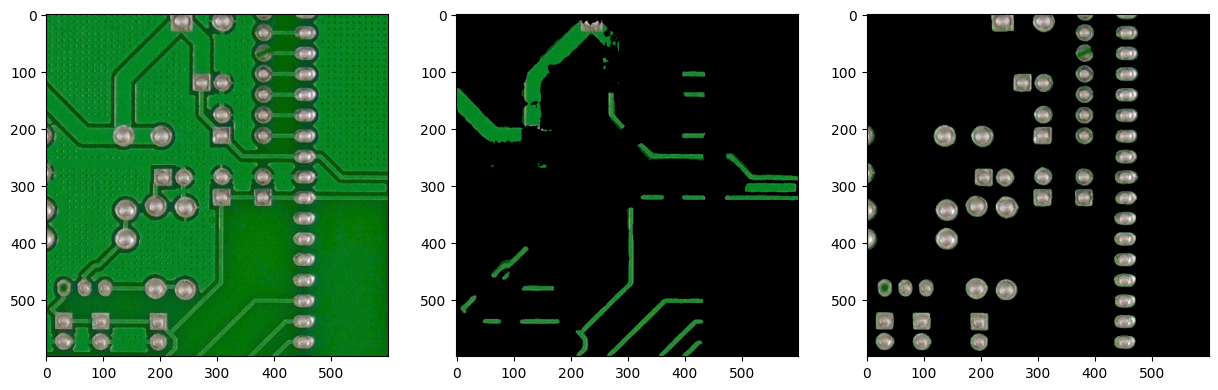

In [26]:
orig = cv2.imread("example.jpg")
copper = cv2.imread("COPPER_TRACES/all_objects_combined.png")
pads = cv2.imread("PADS/all_objects_combined.png")

# Конвертируем BGR в RGB (OpenCV загружает в BGR)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
pads = cv2.cvtColor(pads, cv2.COLOR_BGR2RGB)
copper = cv2.cvtColor(copper, cv2.COLOR_BGR2RGB)

# Создаём подграфики (1 строка, 3 колонки)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Отображаем изображения
axes[0].imshow(orig)
axes[1].imshow(copper)
axes[2].imshow(pads)